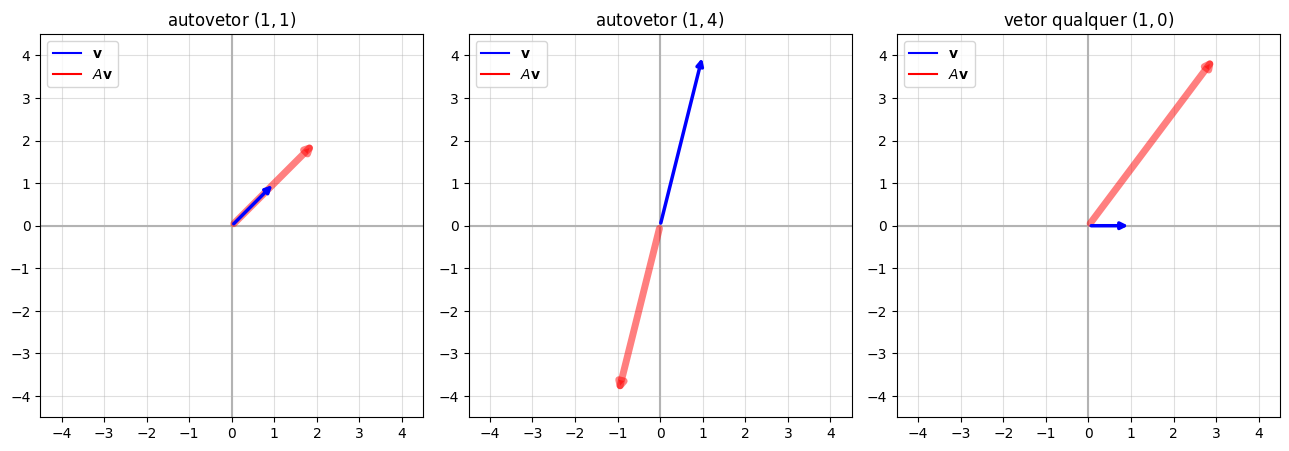

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

A = np.array([[3, -1], [4, -2]])
vetores = [(np.array([1, 1]), 'autovetor $(1,1)$'),
           (np.array([1, 4]), 'autovetor $(1,4)$'),
           (np.array([1, 0]), 'vetor qualquer $(1,0)$')]

fig, axs = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (v, titulo) in zip(axs, vetores):
    Av = A @ v
    ax.annotate('', xy=Av, xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='r', lw=5, alpha=0.5))
    ax.annotate('', xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='b', lw=2.5))
    ax.plot([], [], 'b', label='$\\mathbf{v}$'); ax.plot([], [], 'r', label='$A\\mathbf{v}$')
    lim = max(4.5, np.abs(Av).max() + 0.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.axhline(0, color='0.7'); ax.axvline(0, color='0.7'); ax.grid(True, alpha=0.4)
    ax.set_title(titulo); ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
A = np.array([[3, -1], [4, -2]])
autovalores, autovetores = np.linalg.eig(A)
print("autovalores:", autovalores)
print("autovetores (colunas, normalizados):\n", autovetores)
print("dividindo cada coluna pela primeira componente:\n", autovetores / autovetores[0])

print()
B = sp.Matrix([[0, 1, 1], [1, 0, 1], [1, 1, 0]])
for valor, multiplicidade, vetores in B.eigenvects():
    print("autovalor", valor, "(multiplicidade", multiplicidade, ") -> autovetores:", [list(v) for v in vetores])

autovalores: [ 2. -1.]
autovetores (colunas, normalizados):
 [[0.70710678 0.24253563]
 [0.70710678 0.9701425 ]]
dividindo cada coluna pela primeira componente:
 [[1. 1.]
 [1. 4.]]

autovalor -1 (multiplicidade 2 ) -> autovetores: [[-1, 1, 0], [-1, 0, 1]]
autovalor 2 (multiplicidade 1 ) -> autovetores: [[1, 1, 1]]


autovalores: [-0.00886656 -0.45113344]


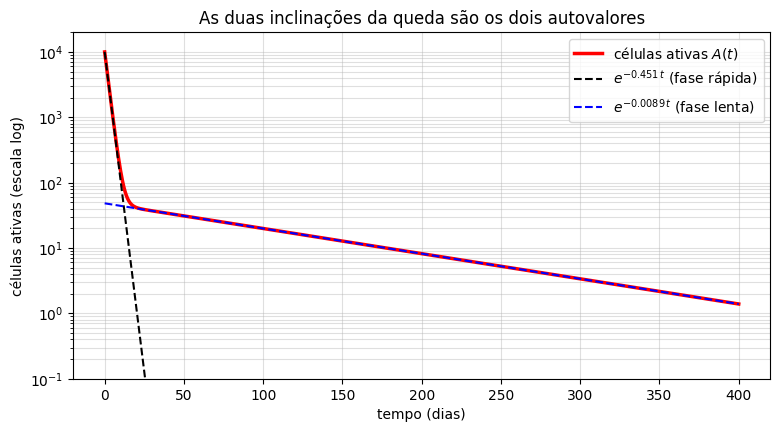

In [3]:
from scipy.integrate import solve_ivp

M = np.array([[-0.01, 0.05], [0.01, -0.45]])
lam = np.linalg.eigvals(M)
print("autovalores:", lam)

t = np.linspace(0, 400, 1000)
sol = solve_ivp(lambda t, x: M @ x, (0, 400), [1e3, 1e4], t_eval=t, rtol=1e-9, atol=1e-12)
A_t = sol.y[1]

plt.figure(figsize=(9, 4.5))
plt.semilogy(t, A_t, 'r', linewidth=2.5, label='células ativas $A(t)$')
plt.semilogy(t, 1e4*np.exp(lam.min()*t), 'k--', label=fr'$e^{{{lam.min():.3f}\,t}}$ (fase rápida)')
plt.semilogy(t, A_t[-1]*np.exp(lam.max()*(t - t[-1])), 'b--', label=fr'$e^{{{lam.max():.4f}\,t}}$ (fase lenta)')
plt.ylim(1e-1, 2e4)
plt.xlabel("tempo (dias)"); plt.ylabel("células ativas (escala log)")
plt.title("As duas inclinações da queda são os dois autovalores")
plt.legend(); plt.grid(True, which='both', alpha=0.4)
plt.show()